#  Advanced Python for AI and ML 
## Module 1 Notebook: Generating Synthetic Datasets

**Notebook title:** `loading_data.ipynb`

This notebook introduces practical file and dataset handling in Python. It covers:


1. Generating synthetic data with NumPy
2. Building a regression example using student performance data
3. Converting a regression target into a classification label
4. Generating synthetic datasets with scikit-learn:
   - `make_regression`
   - `make_classification`
   - `make_blobs`

 

In [1]:
from pathlib import Path

import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Display settings for cleaner notebook output
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 3)   

# Create a data folder for the files generated by this notebook.
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"Data folder is ready: {DATA_DIR.resolve()}")


Data folder is ready: C:\Users\willi\William-Codes\advanced-python\Module-1\data


## 8. Generating a Synthetic Student Performance Dataset

Synthetic data is artificial data generated to support experimentation, teaching, prototyping, or testing.

Here we generate a realistic student performance dataset with:

| Variable | Role | Description |
|---|---|---|
| `study_hours` | Feature | Average weekly study hours |
| `attendance_rate` | Feature | Attendance percentage |
| `previous_grade` | Feature | Prior academic performance |
| `final_grade` | Target for regression | Numeric grade from 0 to 100 |
| `pass_fail_label` | Target for classification | Pass if grade is at least 50, fail otherwise |

We intentionally build a relationship where more study time, stronger attendance, and stronger previous performance tend to increase the final grade. We also add random noise because real educational data is never perfectly deterministic.

In [76]:
# Random generation without seed (different each run)
random_without_seed = np.random.default_rng().integers(1, 100, size=250)

# Random generation with seed (same each run) 
# We use a fixed seed to ensure reproducibility.
random_with_seed = np.random.default_rng(seed=42).integers(1, 100, size=250)

print("Without seed:\n", random_without_seed)
print("With seed (42):\n", random_with_seed) 

 

Without seed:
 [69 70 53 55 92 13 80 61 54 44 22  9 60 71 33 14 37 14 63 74 48 96 94 12
 54 31 39 42 29 55 22 12 87 13 77 81 84  3 48  6 30 89 44 64 52 40 50 62
 84 83 65 67 38 53 93 57 29 51 27 90 35 20 86 65 92 99 55 66  8  3 91 91
 50 78 64 48 35  7 98 72 97 83  5  4 29 46  5  4 87 99  3 34 75 42 86 88
 45 17 74 18 50  7 32 60 23 45 44 63 92 92 43 35 20 51 26 84  9 72 93 62
 98 26 55 43 81  2 70 59 78 93 98 72 83 60 40 67 39 45 85 51 12 92  1 52
 98 99 77 46 15 84 66 84 79 77 82 59 63 99 97 94 81 72  2 29 49 46 98 72
 71 47 24 23 46 73 88 42 50 70 23 68 19 67 31 65 26 42 41 23 67 97 46 29
 60 84 73 80 89 64 20 68 30 18  2 12 52  8 52 23 86  3 73 71 52 33 94 35
 84 23 80 39 21 72 40 24 82 80 39 22 42  1 12 21 75 20 80 63 93 87 47  3
 33 49  3  1 78 36 97 94 15 18]
With seed (42):
 [ 9 77 65 44 43 86  9 70 20 10 53 97 73 76 72 78 51 13 84 45 50 37 19 92
 78 64 40 82 54 44 45 23 10 55 88  7 85 82 28 63 17 76 70 36  7 97 45 89
 68 78 76 20 37 47 50  5 55 16 74 68 92 74 37 96 41 33 90 37

For synthetic data, we often create them on a normal distribution"

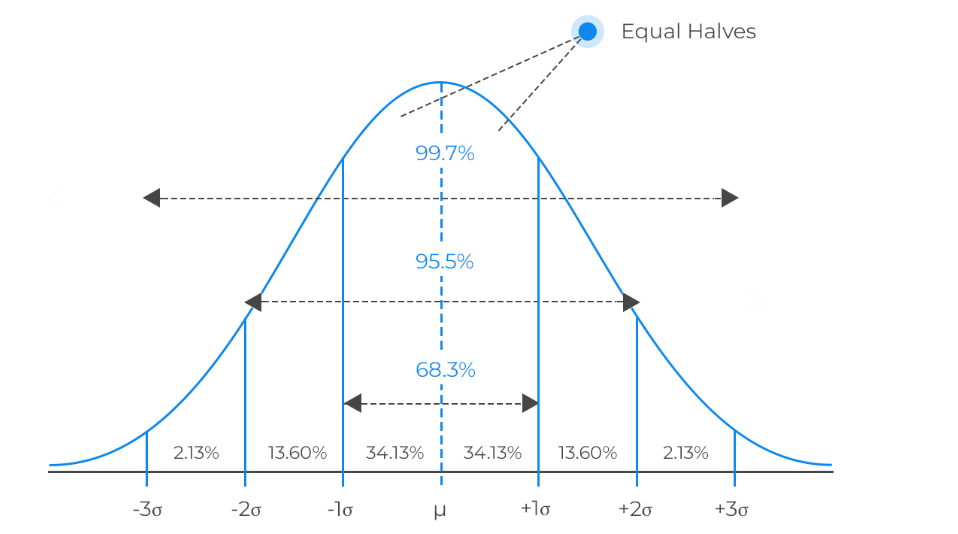

In [89]:
rng = np.random.default_rng(seed=42) # RNG = Random Number Generator

n_students = 250

study_hours = rng.normal(loc=5.0, scale=2.0, size=n_students)
study_hours = np.clip(study_hours, 0, 12)  # Controlling the outliers


attendance_rate = rng.normal(loc=78, scale=12, size=n_students)
attendance_rate = np.clip(attendance_rate, 40, 100)


previous_grade = rng.normal(loc=70, scale=15, size=n_students)
previous_grade = np.clip(previous_grade, 0, 100)

noise = rng.normal(loc=0, scale=8, size=n_students)


# final_grade = rng.normal(loc=70, scale=15, size=n_students) # less realistic final grade distribution

# A more realistic final grade based on a combination of the features and some noise.
final_grade = (
    + 4.2 * study_hours
    + 0.30 * attendance_rate
    + 0.35 * previous_grade
    + noise
)

final_grade = np.clip(final_grade, 0, 100) # to eliminate any unrealistic final grades outside the 0-100 range.

student_performance = pd.DataFrame({
    "study_hours": study_hours.round(2),
    "attendance_rate": attendance_rate.round(2),
    "previous_grade": previous_grade.round(2),
    "final_grade": final_grade.round(2)
})



student_performance["pass_fail_label"] = np.where(
    student_performance["final_grade"] >= 50,
    "Pass",
    "Fail"
)

student_performance


,study_hours,attendance_rate,previous_grade,final_grade,pass_fail_label
0,5.61,73.58,90.46,77.39,Pass
1,2.92,82.10,83.43,63.70,Pass
2,6.50,98.74,59.21,69.53,Pass
3,6.88,66.16,47.46,81.75,Pass
4,1.10,75.06,25.53,50.35,Pass
...,...,...,...,...,...
245,2.43,89.23,83.96,69.16,Pass
246,2.81,56.02,96.96,68.67,Pass
247,8.67,73.97,77.74,86.80,Pass
248,10.81,54.11,64.42,85.23,Pass


### 8.1 Inspecting the Synthetic Dataset

In [91]:
print("Shape:", student_performance.shape)

display(student_performance.describe())

print("\nPass/fail distribution:")
display(student_performance["pass_fail_label"].value_counts())

Shape: (250, 5)


,study_hours,attendance_rate,previous_grade,final_grade
count,250.000,250.000,250.000,250.000
mean,4.903,78.174,68.268,68.080
std,1.881,11.548,15.273,12.270
min,0.710,47.200,25.530,35.890
25%,3.542,70.970,57.080,59.595
50%,4.785,78.980,68.215,68.675
75%,6.042,85.595,78.612,77.218
max,10.830,100.000,100.000,100.000



Pass/fail distribution:


pass_fail_label
Pass    231
Fail     19
Name: count, dtype: int64

### 8.2 Visualizing Relationships in the Synthetic Dataset (Part of EDA)

These plots help us inspect whether the generated data behaves as expected.

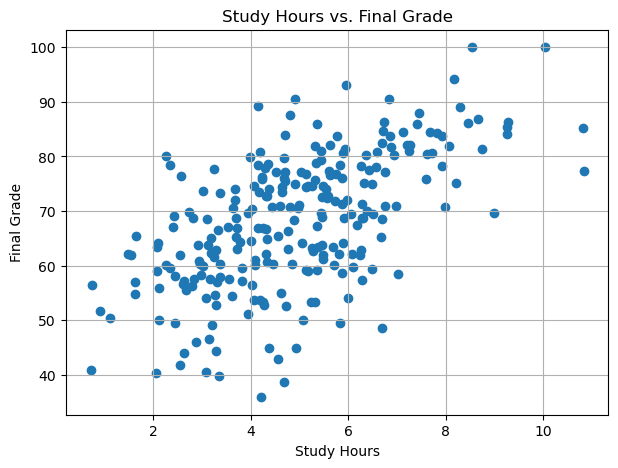

In [102]:
plt.figure(figsize=(7, 5))
plt.scatter(student_performance["study_hours"], student_performance["final_grade"])
plt.xlabel("Study Hours")
plt.ylabel("Final Grade")
plt.title("Study Hours vs. Final Grade")   
plt.grid(True)
plt.show()

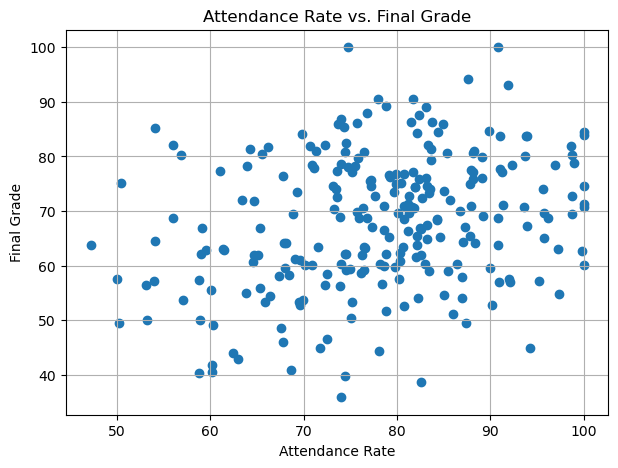

In [104]:
plt.figure(figsize=(7, 5))
plt.scatter(student_performance["attendance_rate"], student_performance["final_grade"])
plt.xlabel("Attendance Rate")
plt.ylabel("Final Grade")
plt.title("Attendance Rate vs. Final Grade")
plt.grid(True)
plt.show()

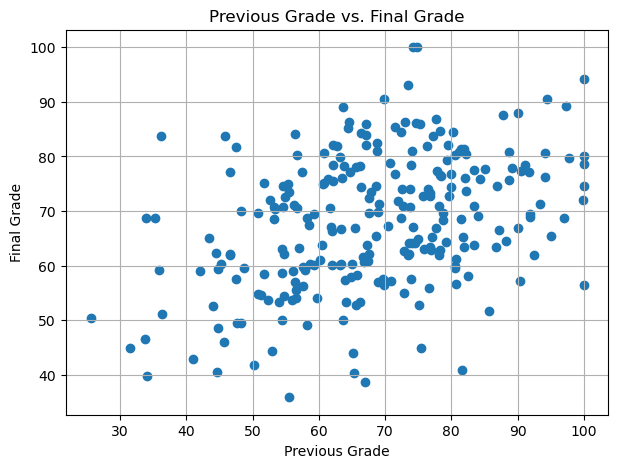

In [105]:
plt.figure(figsize=(7, 5))
plt.scatter(student_performance["previous_grade"], student_performance["final_grade"])
plt.xlabel("Previous Grade")
plt.ylabel("Final Grade")
plt.title("Previous Grade vs. Final Grade")
plt.grid(True)
plt.show()

Boxplot: Useful for statistical analysis
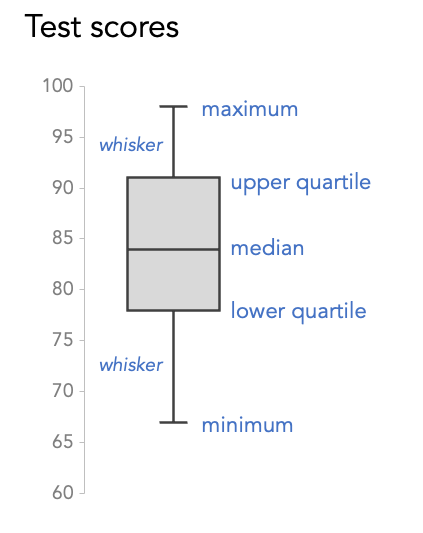

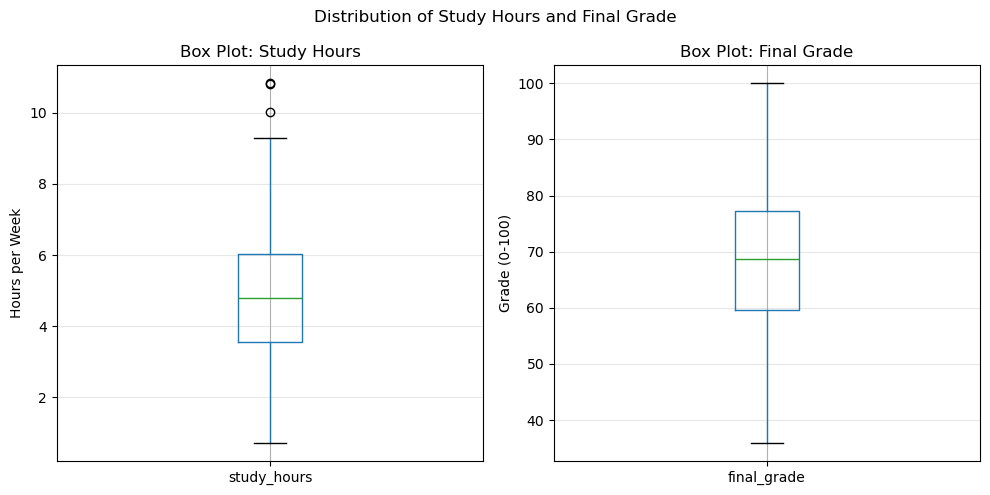

How to read a box plot:
- Middle line in the box = median (typical value).
- Bottom and top of box = 25th and 75th percentiles (middle 50% of data).
- Whiskers = typical low/high range.
- Points outside whiskers = potential outliers.


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

student_performance.boxplot(column="study_hours", ax=axes[0])
axes[0].set_title("Box Plot: Study Hours")
axes[0].set_ylabel("Hours per Week")
axes[0].grid(True, axis="y", alpha=0.3)

student_performance.boxplot(column="final_grade", ax=axes[1])
axes[1].set_title("Box Plot: Final Grade")
axes[1].set_ylabel("Grade (0-100)")
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Distribution of Study Hours and Final Grade")
plt.tight_layout()
plt.show()

print(
    "How to read a box plot:\n"
    "- Middle line in the box = median (typical value).\n"
    "- Bottom and top of box = 25th and 75th percentiles (middle 50% of data).\n"
    "- Whiskers = typical low/high range.\n"
    "- Points outside whiskers = potential outliers."
)

### 8.3 Saving the Synthetic Dataset

In [108]:
synthetic_csv_path = DATA_DIR / "student_performance_synthetic.csv"
synthetic_json_path = DATA_DIR / "student_performance_synthetic.json"
pickle_path = DATA_DIR / "student_performance_synthetic.pkl"

student_performance.to_csv(synthetic_csv_path, index=False)
student_performance.to_json(synthetic_json_path, orient="records", indent=4)

# Let's also store in the pickle format for easy loading in Python later.
student_performance.to_pickle(pickle_path)


print(f"Synthetic CSV saved to:  {synthetic_csv_path}")
print(f"Synthetic JSON saved to: {synthetic_json_path}")


Synthetic CSV saved to:  data\student_performance_synthetic.csv
Synthetic JSON saved to: data\student_performance_synthetic.json


In [112]:
#let's reload the pickle file to verify it works correctly.
df_imported = pd.read_pickle(pickle_path)
df_imported

,study_hours,attendance_rate,previous_grade,final_grade,pass_fail_label
0,5.61,73.58,90.46,77.39,Pass
1,2.92,82.10,83.43,63.70,Pass
2,6.50,98.74,59.21,69.53,Pass
3,6.88,66.16,47.46,81.75,Pass
4,1.10,75.06,25.53,50.35,Pass
...,...,...,...,...,...
245,2.43,89.23,83.96,69.16,Pass
246,2.81,56.02,96.96,68.67,Pass
247,8.67,73.97,77.74,86.80,Pass
248,10.81,54.11,64.42,85.23,Pass


## 9. Regression Example: Predicting Final Grade

Regression is used when the target variable is numeric.

In this example:

- Features: `study_hours`, `attendance_rate`, `previous_grade`
- Target: `final_grade`
- Model: `LinearRegression`

The model attempts to learn a linear relationship between the input features and the numeric grade.

In [21]:
features = ["study_hours", "attendance_rate", "previous_grade"]
target = "final_grade"

X = student_performance[features]
y = student_performance[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

y_pred = regression_model.predict(X_test)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 200
Testing records: 50


### 9.1 Regression Evaluation

Common regression metrics include:

| Metric | Meaning |
|---|---|
| MAE | Average absolute prediction error |
| MSE | Average squared prediction error |
| RMSE | Square root of MSE, in the same unit as the target |
| R² | Proportion of target variance explained by the model |

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error:  {mse:.2f}")
print(f"Root MSE:            {rmse:.2f}")
print(f"R-squared:           {r2:.3f}")

Mean Absolute Error: 5.42
Mean Squared Error:  53.54
Root MSE:            7.32
R-squared:           0.689


### 9.2 Interpreting Regression Coefficients

For a linear regression model, each coefficient estimates how much the predicted target changes when that feature increases by one unit, holding other features constant.

In [23]:
coefficient_table = pd.DataFrame({
    "feature": features,
    "coefficient": regression_model.coef_
})

coefficient_table

,feature,coefficient
0,study_hours,3.646
1,attendance_rate,0.277
2,previous_grade,0.321


In [24]:
print(f"Intercept: {regression_model.intercept_:.2f}")

for feature_name, coefficient in zip(features, regression_model.coef_):
    print(f"{feature_name}: {coefficient:.3f}")

Intercept: 14.84
study_hours: 3.646
attendance_rate: 0.277
previous_grade: 0.321


### 9.3 Predicting the Grade for a New Student

In [25]:
new_student = pd.DataFrame({
    "study_hours": [6.5],
    "attendance_rate": [90],
    "previous_grade": [78]
})

predicted_grade = regression_model.predict(new_student)[0]

print(f"Predicted final grade: {predicted_grade:.2f}")

Predicted final grade: 88.51


## 10. Classification Example: Predicting Pass or Fail

Classification is used when the target variable is categorical.

We already created the `pass_fail_label` column:

- `Fail` if `final_grade < 50`
- `Pass` if `final_grade >= 50`

Now we train a simple classifier to predict the pass/fail label using the same input features.

In [26]:
classification_target = "pass_fail_label"

X_cls = student_performance[features]
y_cls = student_performance[classification_target]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

classification_model = LogisticRegression(max_iter=1000)
classification_model.fit(X_train_cls, y_train_cls)

y_pred_cls = classification_model.predict(X_test_cls)

print("Training records:", X_train_cls.shape[0])
print("Testing records:", X_test_cls.shape[0])

Training records: 200
Testing records: 50


### 10.1 Classification Evaluation

Common classification metrics include:

| Metric | Meaning |
|---|---|
| Accuracy | Overall proportion of correct predictions |
| Precision | How many predicted positives were actually positive |
| Recall | How many actual positives were correctly identified |
| F1-score | Harmonic mean of precision and recall |
| Confusion matrix | Table of actual vs. predicted classes |

In [27]:
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls, pos_label="Pass")
recall = recall_score(y_test_cls, y_pred_cls, pos_label="Pass")
f1 = f1_score(y_test_cls, y_pred_cls, pos_label="Pass")

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.980
Precision: 0.980
Recall:    1.000
F1-score:  0.990


In [28]:
labels = ["Fail", "Pass"]

cm = confusion_matrix(y_test_cls, y_pred_cls, labels=labels)

confusion_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

confusion_df

,Predicted Fail,Predicted Pass
Actual Fail,0,1
Actual Pass,0,49


In [29]:
print(classification_report(y_test_cls, y_pred_cls))

              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         1
        Pass       0.98      1.00      0.99        49

    accuracy                           0.98        50
   macro avg       0.49      0.50      0.49        50
weighted avg       0.96      0.98      0.97        50



c:\Users\willi\anaconda3\envs\william-ml-3-12-12\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willi\anaconda3\envs\william-ml-3-12-12\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willi\anaconda3\envs\william-ml-3-12-12\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

### 10.2 Predicting Pass or Fail for a New Student

In [30]:
predicted_label = classification_model.predict(new_student)[0]
predicted_probabilities = classification_model.predict_proba(new_student)[0]

print(f"Predicted label: {predicted_label}")

probability_table = pd.DataFrame({
    "class": classification_model.classes_,
    "probability": predicted_probabilities
})

probability_table

Predicted label: Pass


,class,probability
0,Fail,4.288e-04
1,Pass,9.996e-01


## 11. scikit-learn Synthetic Dataset Generators

The `sklearn.datasets` module includes several functions for creating simulated datasets.

Three common functions are:

| Function | Main Use |
|---|---|
| `make_regression()` | Generates data for regression problems |
| `make_classification()` | Generates data for classification problems |
| `make_blobs()` | Generates clustered data for clustering examples |

These functions are useful because they allow us to control the number of samples, number of features, noise level, and other properties of the dataset.

## 12. `make_regression()` Example

`make_regression()` creates a synthetic dataset where the target is continuous. This is useful for demonstrating linear regression.

In this example, we create:

- 100 samples
- 3 features
- 1 numeric target
- Some noise, so the relationship is not perfectly linear

In [31]:
X_reg, y_reg = make_regression(
    n_samples=100,
    n_features=3,
    noise=10,
    random_state=42
)

print("Feature data type:", type(X_reg))
print("Target data type:", type(y_reg))
print("Feature shape:", X_reg.shape)
print("Target shape:", y_reg.shape)

Feature data type: <class 'numpy.ndarray'>
Target data type: <class 'numpy.ndarray'>
Feature shape: (100, 3)
Target shape: (100,)


In [32]:
regression_df = pd.DataFrame(
    X_reg,
    columns=["feature_1", "feature_2", "feature_3"]
)

regression_df["target"] = y_reg

regression_df.head()

,feature_1,feature_2,feature_3,target
0,-0.793,0.505,-0.115,12.781
1,0.281,-0.208,-0.623,-21.876
2,0.791,1.403,-0.909,91.099
3,0.626,-1.071,-0.857,-82.266
4,-0.343,-0.161,-0.802,-30.417


### 12.1 Quick Regression Model with `make_regression()`

In [33]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    regression_df[["feature_1", "feature_2", "feature_3"]],
    regression_df["target"],
    test_size=0.20,
    random_state=42
)

model_reg = LinearRegression()
model_reg.fit(X_train_reg, y_train_reg)

pred_reg = model_reg.predict(X_test_reg)

print(f"R-squared: {r2_score(y_test_reg, pred_reg):.3f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test_reg, pred_reg)):.2f}")

R-squared: 0.982
RMSE:      11.13


## 13. `make_classification()` Example

`make_classification()` creates a synthetic dataset for classification.

In this example, we create:

- 100 samples
- 3 features
- 2 classes
- 2 informative features
- 0 redundant features

The generated target values are class labels.

In [34]:
X_class, y_class = make_classification(
    n_samples=100,
    n_features=3,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

print("Feature data type:", type(X_class))
print("Target data type:", type(y_class))
print("Feature shape:", X_class.shape)
print("Target shape:", y_class.shape)

Feature data type: <class 'numpy.ndarray'>
Target data type: <class 'numpy.ndarray'>
Feature shape: (100, 3)
Target shape: (100,)


In [35]:
classification_df = pd.DataFrame(
    X_class,
    columns=["feature_1", "feature_2", "feature_3"]
)

classification_df["target"] = y_class

classification_df.head()

,feature_1,feature_2,feature_3,target
0,1.278,1.355,1.155,1
1,1.267,1.023,-1.083,1
2,0.405,1.805,-0.150,1
3,-0.652,-1.560,-1.925,0
4,-0.060,0.254,-1.795,1


In [36]:
classification_df["target"].value_counts().sort_index()

target
0    50
1    50
Name: count, dtype: int64

### 13.1 Quick Classification Model with `make_classification()`

In [37]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    classification_df[["feature_1", "feature_2", "feature_3"]],
    classification_df["target"],
    test_size=0.20,
    random_state=42,
    stratify=classification_df["target"]
)

model_class = LogisticRegression(max_iter=1000)
model_class.fit(X_train_class, y_train_class)

pred_class = model_class.predict(X_test_class)

print(f"Accuracy: {accuracy_score(y_test_class, pred_class):.3f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test_class, pred_class))

Accuracy: 1.000

Confusion matrix:
[[10  0]
 [ 0 10]]


## 14. `make_blobs()` Example

A **blob** is a group of points generated around a center. In machine learning, `make_blobs()` is often used to create artificial clusters.

This is useful for teaching clustering because the data naturally forms visible groups.

In this example, we create:

- 100 samples
- 2 features
- 3 cluster centers
- A cluster label for each record

The cluster labels are known because the data is synthetic. In real clustering problems, the goal is often to discover such groups without having labels in advance.

In [38]:
X_blob, y_blob = make_blobs(
    n_samples=100,
    n_features=2,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

blob_df = pd.DataFrame(
    X_blob,
    columns=["feature_1", "feature_2"]
)

blob_df["cluster_id"] = y_blob

blob_df.head()

,feature_1,feature_2,cluster_id
0,-7.896,-8.698,2
1,5.616,0.496,1
2,-3.073,9.665,0
3,6.323,0.291,1
4,-6.450,-6.207,2


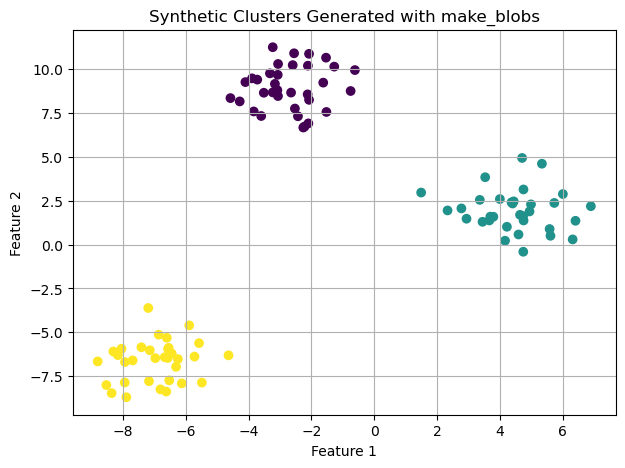

In [39]:
plt.figure(figsize=(7, 5))
plt.scatter(
    blob_df["feature_1"],
    blob_df["feature_2"],
    c=blob_df["cluster_id"]
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Clusters Generated with make_blobs")
plt.grid(True)
plt.show()

## 15. Saving scikit-learn Generated Datasets

In [40]:
regression_df.to_csv(DATA_DIR / "sklearn_make_regression.csv", index=False)
classification_df.to_csv(DATA_DIR / "sklearn_make_classification.csv", index=False)
blob_df.to_csv(DATA_DIR / "sklearn_make_blobs.csv", index=False)

print("Saved generated datasets:")
print("- sklearn_make_regression.csv")
print("- sklearn_make_classification.csv")
print("- sklearn_make_blobs.csv")

Saved generated datasets:
- sklearn_make_regression.csv
- sklearn_make_classification.csv
- sklearn_make_blobs.csv


## 16. Student Practice Tasks

Complete the following tasks after running the notebook:

### Task 1: CSV and JSON Loading
1. Open the generated `students_sample.csv` file.
2. Load it using `pd.read_csv()`.
3. Set `student_id` as the index.
4. Display only students with `final_grade >= 70`.

### Task 2: Data Manipulation
1. Add a new column called `grade_band`.
2. Use the following categories:
   - `A` for grades 80 and above
   - `B` for grades 70 to 79
   - `C` for grades 60 to 69
   - `D` for grades 50 to 59
   - `F` for grades below 50
3. Save the updated DataFrame as `students_with_grade_band.csv`.

### Task 3: Regression
1. Change the number of generated students from 250 to 500.
2. Train the regression model again.
3. Compare the new R² score with the previous one.
4. Explain whether adding more synthetic records improved the model.

### Task 4: Classification
1. Change the pass/fail threshold from 50 to 60.
2. Recreate the `pass_fail_label`.
3. Train the classification model again.
4. Compare the confusion matrix before and after the change.

### Task 5: Blobs
1. Change the number of cluster centers from 3 to 4.
2. Plot the new blobs.
3. Explain how the number of clusters affects the visualization.

## 17. Key Takeaways

1. CSV is a common format for tabular data and can be loaded with `pd.read_csv()`.
2. JSON is common in web applications and APIs and can be loaded with `pd.read_json()`.
3. Pandas DataFrames can be saved using `to_csv()` and `to_json()`.
4. Synthetic data is useful for teaching, testing, and prototyping.
5. Numeric targets support regression tasks.
6. Categorical labels support classification tasks.
7. `make_regression()`, `make_classification()`, and `make_blobs()` provide controlled ways to generate data for machine learning examples.